<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2025-07-22 07:14:16--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  58.7MB/s    in 3.4s    

2025-07-22 07:14:20 (59.2 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install numpy

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#### Connect to the SQLite database


In [2]:
conn = sqlite3.connect('survey-data.sqlite')

QUERY = "SELECT * FROM main"
df = pd.read_sql_query(QUERY, conn)

# Display the results
print(df)

       ResponseId                      MainBranch                 Age  \
0               1  I am a developer by profession  Under 18 years old   
1               2  I am a developer by profession     35-44 years old   
2               3  I am a developer by profession     45-54 years old   
3               4           I am learning to code     18-24 years old   
4               5  I am a developer by profession     18-24 years old   
...           ...                             ...                 ...   
65432       65433  I am a developer by profession     18-24 years old   
65433       65434  I am a developer by profession     25-34 years old   
65434       65435  I am a developer by profession     25-34 years old   
65435       65436  I am a developer by profession     18-24 years old   
65436       65437     I code primarily as a hobby     18-24 years old   

                Employment                            RemoteWork   Check  \
0      Employed, full-time                     

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [ ]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


**Demo 2: List all tables**


In [ ]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


**Demo 3: Group data by age**


In [ ]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


/tmp/ipykernel_1549/3013989799.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.loc[:, "LogCompTotal"] = np.log1p(df_filtered["CompTotal"])


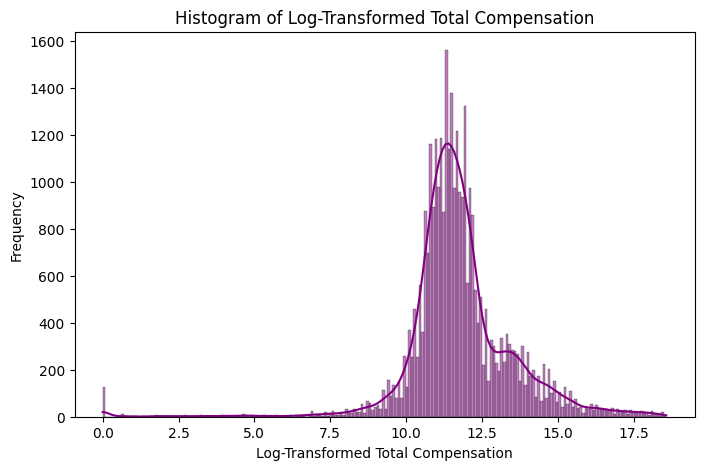

In [15]:
## Write your code here
# Convert to numeric
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")

# Remove extreme outliers (top 1%)
q99 = df["CompTotal"].quantile(0.99)
df_filtered = df[df["CompTotal"] < q99]

# Apply log transformation
df_filtered.loc[:, "LogCompTotal"] = np.log1p(df_filtered["CompTotal"])

# Plot histogram using seaborn
plt.figure(figsize=(8, 5))
sns.histplot(df_filtered["LogCompTotal"], bins='auto', kde=True, color="purple")
plt.xlabel("Log-Transformed Total Compensation")
plt.ylabel("Frequency")
plt.title("Histogram of Log-Transformed Total Compensation")
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


In [ ]:
## Write your code here

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


/tmp/ipykernel_1549/954618179.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Age Group", bbox_to_anchor=(1, 1), loc="upper left")


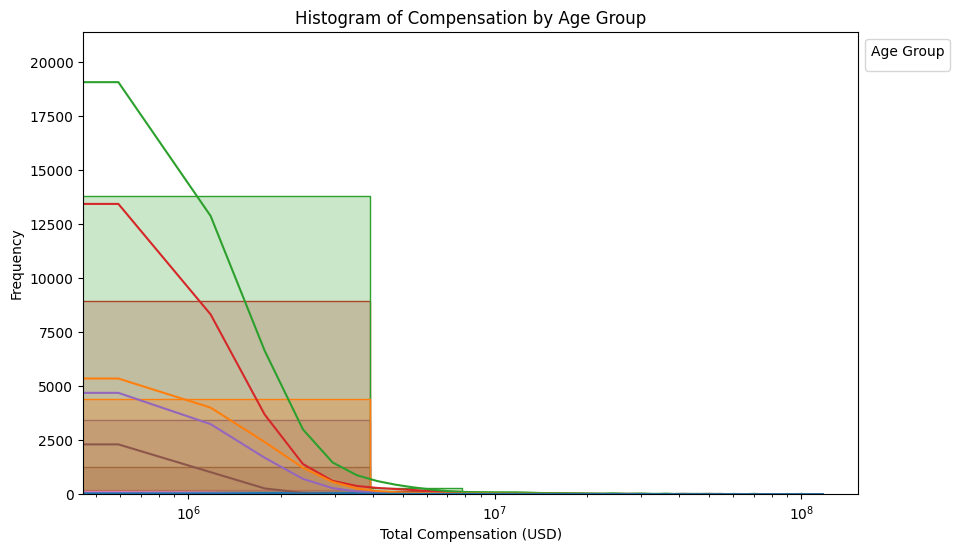

In [39]:
# Define age categories in order
age_order = [
    "Under 18 years old", "18-24 years old", "25-34 years old", 
    "35-44 years old", "45-54 years old", "55-64 years old", 
    "65 years or older"
]

# Ensure Age is categorical
df["Age"] = pd.Categorical(df["Age"], categories=age_order, ordered=True)

# Convert CompTotal to numeric & drop NaNs
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")
df = df.dropna(subset=["CompTotal", "Age"])  # Ensure non-empty age groups

# Remove extreme outliers (top 1%)
q99 = df["CompTotal"].quantile(0.99)
df_filtered = df[df["CompTotal"] < q99]

# Plot histograms for each Age group
plt.figure(figsize=(10, 6))
sns.histplot(data=df_filtered, x="CompTotal", hue="Age", bins=30, kde=True, element="step")

# Labels and title
plt.xlabel("Total Compensation (USD)")
plt.ylabel("Frequency")
plt.title("Histogram of Compensation by Age Group")
plt.xscale("log")  # Log scale for better visualization
plt.legend(title="Age Group", bbox_to_anchor=(1, 1), loc="upper left")

# Show plot
plt.show()

In [34]:
print(df_filtered["Age"].value_counts(dropna=False))

Age
25-34 years old       14466
35-44 years old        9291
18-24 years old        4568
45-54 years old        3503
55-64 years old        1275
65 years or older       196
Under 18 years old       89
Name: count, dtype: int64


**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


In [21]:
## Write your code here
# Define ordered age categories
age_order = [
    "Under 18 years old", "18-24 years old", "25-34 years old", 
    "35-44 years old", "45-54 years old", "55-64 years old", 
    "65 years or older"
]

# Ensure Age is categorical
df["Age"] = pd.Categorical(df["Age"], categories=age_order, ordered=True)

# Convert TimeSearching to numeric & drop NaNs
df["TimeSearching"] = pd.to_numeric(df["TimeSearching"], errors="coerce")
df = df.dropna(subset=["TimeSearching", "Age"])  # Drop missing values

# Check if Age has valid categories left
if df["Age"].nunique() > 1:  # Ensure multiple age groups exist
    plt.figure(figsize=(12, 6))
    ax = sns.histplot(data=df, x="TimeSearching", hue="Age", bins=30, kde=True, element="step")

    # Labels and title
    plt.xlabel("Time Spent Searching for Information (Minutes)")
    plt.ylabel("Frequency")
    plt.title("Histogram of Time Searching by Age Group")

    # Ensure legend appears
    handles, labels = ax.get_legend_handles_labels()
    if labels:  # Only add legend if labels exist
        plt.legend(handles, labels, title="Age Group", bbox_to_anchor=(1.05, 1), loc="upper left")

    # Show plot
    plt.show()
else:
    print("No valid Age groups available after filtering.")

No valid Age groups available after filtering.


### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


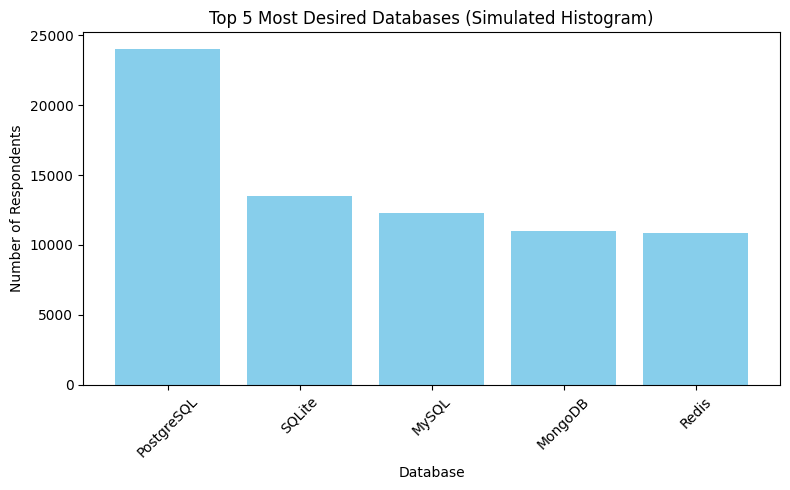

In [13]:
## Write your code 

# Step 1: Split multi-selection into list
df_db = df.copy()
df_db['DatabaseWantToWorkWith'] = df_db['DatabaseWantToWorkWith'].dropna().str.split(';')

# Step 2: Explode to multiple rows
df_db = df_db.explode('DatabaseWantToWorkWith')

# Step 3: Get top 5 databases
top_5 = df_db['DatabaseWantToWorkWith'].value_counts().nlargest(5)

plt.figure(figsize=(8, 5))
plt.bar(top_5.index, top_5.values, color='skyblue')  # use bar instead of hist for clean labeling
plt.title('Top 5 Most Desired Databases (Simulated Histogram)')
plt.xlabel('Database')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


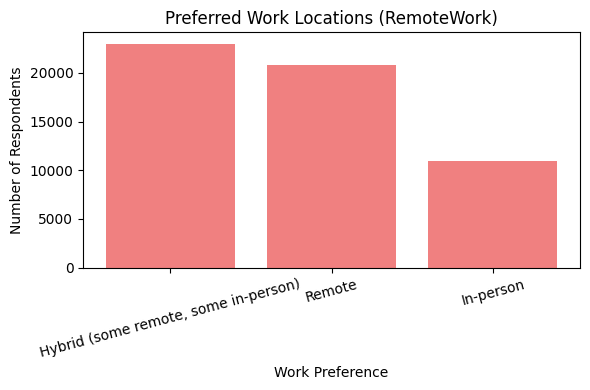

In [14]:
## Write your code here
# Simple frequency count for RemoteWork
remote_counts = df['RemoteWork'].value_counts()

# Plot
plt.figure(figsize=(6, 4))
plt.bar(remote_counts.index, remote_counts.values, color='lightcoral')
plt.title('Preferred Work Locations (RemoteWork)')
plt.xlabel('Work Preference')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


/tmp/ipykernel_526/3675371133.py:18: RuntimeWarning: divide by zero encountered in log10
  np.log10(df_filtered["CompTotal"].min()),
/opt/conda/lib/python3.12/site-packages/numpy/_core/function_base.py:162: RuntimeWarning: invalid value encountered in multiply
  y *= step
/opt/conda/lib/python3.12/site-packages/numpy/_core/function_base.py:172: RuntimeWarning: invalid value encountered in add
  y += start
/opt/conda/lib/python3.12/site-packages/seaborn/distributions.py:669: FutureWarning: The behavior of Series.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  thin_bar_idx = hist_metadata["widths"].idxmin()


KeyError: nan

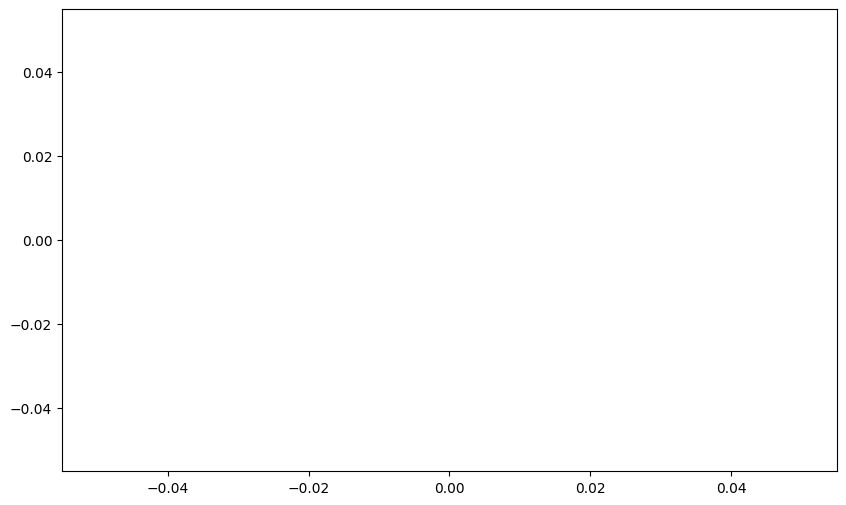

In [3]:
## Write your code here
# Define numeric mapping for age groups
age_mapping = {
    '45-54 years old': 49.5,
    '55-64 years old': 59.5
}

# Filter for ages 45-60
df_filtered = df[df["Age"].isin(age_mapping.keys())].copy()
df_filtered["AgeNumeric"] = df_filtered["Age"].map(age_mapping)

# Convert CompTotal to numeric and drop NaNs
df_filtered["CompTotal"] = pd.to_numeric(df_filtered["CompTotal"], errors="coerce")
df_filtered = df_filtered.dropna(subset=["CompTotal"])

# **Fix: Handle extreme variation using log-based binning**
bin_edges = np.logspace(
    np.log10(df_filtered["CompTotal"].min()), 
    np.log10(df_filtered["CompTotal"].max()), 
    30  # Adjust the number of bins as needed
)

# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_filtered, x="CompTotal", bins=bin_edges, kde=True)

# Labels and title
plt.xlabel("Total Compensation (USD)")
plt.ylabel("Frequency")
plt.title("Histogram of Compensation for Ages 45-60")
plt.xscale("log")  # Log scale for better readability

plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


/tmp/ipykernel_1549/2163960218.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Job Satisfaction", bbox_to_anchor=(1.05, 1), loc="upper left")


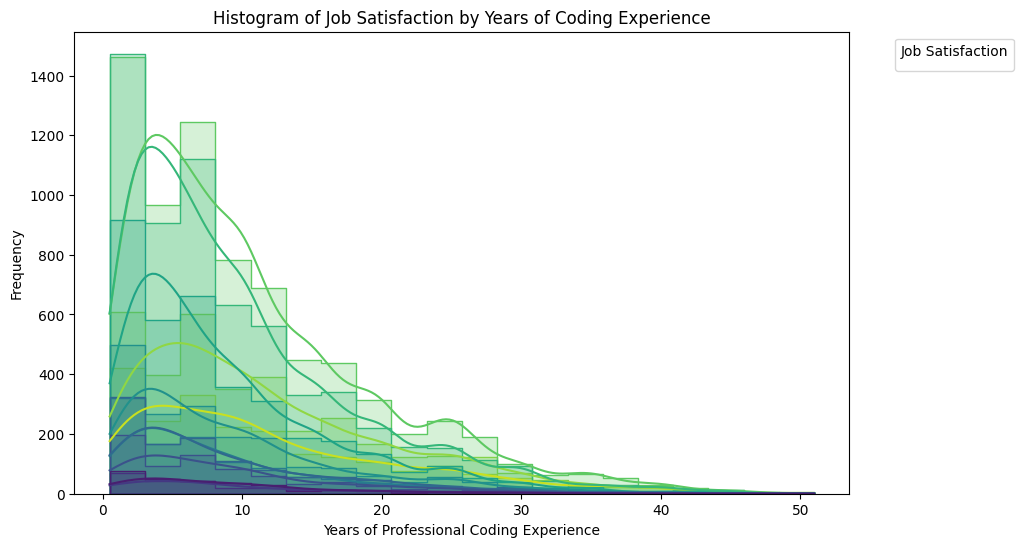

In [27]:
# Ensure JobSat is categorical and drop missing values
df["JobSat"] = df["JobSat"].astype("category")
df_filtered = df.dropna(subset=["JobSat", "YearsCodePro"])  # Ensure both columns have values

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_filtered, x="YearsCodePro", hue="JobSat", bins=20, kde=True, 
    element="step", palette="viridis", legend=True
)

# Labels and title
plt.xlabel("Years of Professional Coding Experience")
plt.ylabel("Frequency")
plt.title("Histogram of Job Satisfaction by Years of Coding Experience")

# Ensure the legend appears
plt.legend(title="Job Satisfaction", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()


### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [4]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
